In [1]:
print('test')

test


### 참고 : 모델	입력 형태	출력 형태
| 모델 | 입력 형태 | 출력 형태 (회귀 예) |
|---|---|---|
| **MLP** | **2차원** `(샘플, feature)` | **2차원** `(샘플, 출력)` |
| **RNN** | **3차원** `(샘플, timestep, feature)` | **보통 2차원** `(샘플, 출력)` |
| **LSTM** | **3차원** `(샘플, timestep, feature)` | **보통 2차원** `(샘플, 출력)` |
| **GRU** | **3차원** `(샘플, timestep, feature)` | **보통 2차원** `(샘플, 출력)` |

### 숫자 예측 모델(LSTM)

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
# 데이터 생성(랜덤 숫자 시퀀스)
data = np.array([i for i in range(1, 21)])
timesteps = 3       # sequence length와 같은 개념

In [8]:
x_data = []
y_data = []

In [9]:
# 타임스텝에 따라 입력 데이터와 출력 데이터 생성
for i in range(len(data)-timesteps):
    x_data.append(data[i : i + timesteps])  # 입력
    y_data.append(data[i + timesteps])    # 출력
    
x_data = np.array(x_data).reshape(-1, timesteps, 1)     # (샘플 수, 타임스텝, 피처 수)
y_data = np.array(y_data)   # 출력값

In [12]:
# LSTM 모델 정의
model = Sequential([
    LSTM(10, input_shape=(timesteps, 1)),  # LSTM 레이어 (유닛: 10)
    Dense(1)    # 출력 레이어
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam', loss='mse')

In [15]:
# 모델 학습
model.fit(x_data, y_data, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 153.6894
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 153.5191
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 153.3495
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 153.1808
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 153.0130
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 152.8459
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 152.6796
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 152.5141
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 152.3493
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 152.1852
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 152.0217
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 151.8589
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 151.6966
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 151.5349
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 

In [16]:
# 예측 테스트
test_input = np.array([18, 19, 20]).reshape(1, timesteps, 1)
predicted_value = model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


In [18]:
# 결과 출력
# flatten함수 : [[[18],[19],[20]]] --> [18,19,20]
print("입력 데이터:", test_input.flatten()) 
print("예측 값:", model.predict(test_input))


입력 데이터: [18 19 20]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
예측 값: [[1.220035]]


### 기온예측 모델(RNN)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [20]:
# 데이터 로드
file_path = "../dataset/jena_climate_2009.csv"
data = pd.read_csv(file_path)

In [21]:
# Date Time: 관측 날짜 및 시간. p (mbar): 기압. T (degC): 기온, Tpot (K): 잠재온도
data.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [22]:
data.shape

(21743, 15)

In [23]:
# T (digC) : 기온
temperature = data['T (degC)'].values

In [24]:
# 데이터 전처리
scaler = MinMaxScaler(feature_range=(0, 1))     # 정규화
scaled_data = scaler.fit_transform(temperature.reshape(-1, 1))

In [25]:
# 데이터셋 생성 함수 : look_back(sequence_length와 같은 의미)
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i : i+look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [26]:
look_back = 60      # 과거 60분 데이터를 기반으로 예측
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))      # RNN 입력 형태

In [27]:
X.shape

(21683, 60, 1)

In [28]:
# 데이터 분리
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [29]:
# RNN 모델 구성
model = Sequential([
    # 50(뉴런 즉 메모리유닛수), return_sequence=False(마지막시점 출력만 반환)
    SimpleRNN(50, return_sequences=False, input_shape=(X.shape[1], 1)), 
    Dense(1)
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [31]:
# 모델 학습
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0026 - val_loss: 6.0752e-04
Epoch 2/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.1690e-04 - val_loss: 2.6255e-04
Epoch 3/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.6023e-04 - val_loss: 1.5715e-04
Epoch 4/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.1721e-04 - val_loss: 1.9507e-04
Epoch 5/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 9.5809e-05 - val_loss: 1.6146e-04
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.0491e-05 - val_loss: 1.1610e-04
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 6.2072e-05 - val_loss: 1.1988e-04
Epoch 8/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.9636e-05 - val_loss: 1.0639e-04
Epoch 9/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.4515e-05 - val_loss: 8.8238e-05
Epoch 10/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.2004e-05 - val_loss: 8.6007e-05
Epoch 11/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.

In [32]:
# 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)     # 정규화 복원

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [33]:
# 실제 값 복원
actual_values = scaler.inverse_transform(y_test.reshape(-1, 1))

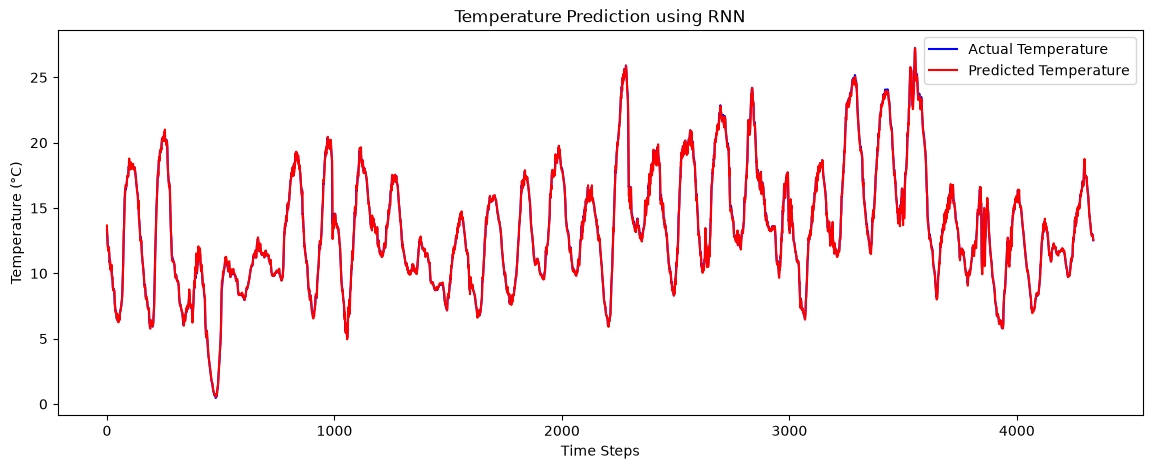

In [34]:
# 6. 시각화
plt.figure(figsize=(14, 5))
plt.plot(actual_values, label="Actual Temperature", color='blue')
plt.plot(predictions, label="Predicted Temperature", color='red')
plt.title('Temperature Prediction using RNN')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

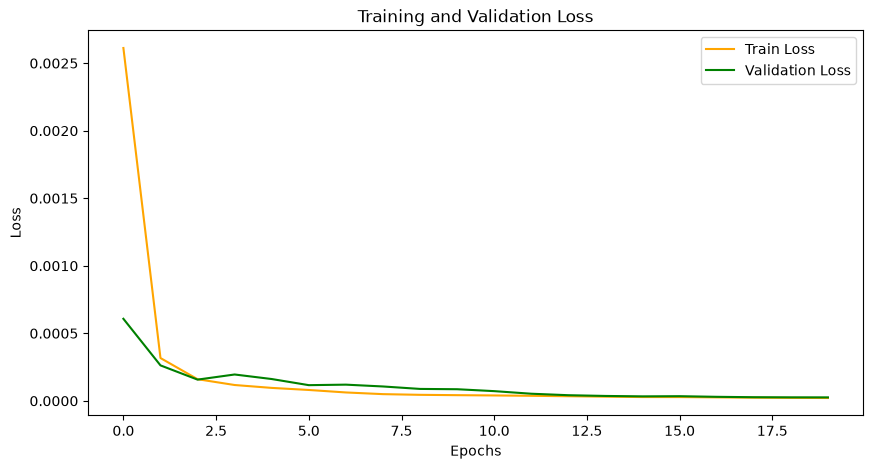

In [35]:
# 7. 학습 손실 시각화
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 주가예측 모델(LSTM)

In [36]:
# 증권 데이터 수집 라이브러리 설치 : pip install yfinance
# 한글 폴더는 에러가 나기 때문에 영문으로 변경
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [42]:
# 데이터 수집
ticker = "AAPL"     # 예: 애플 주식
data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
data = data[['Close']]      # 종가만 사용

[*********************100%***********************]  1 of 1 completed


In [43]:
data.head()

Price,Close
Ticker,AAPL
Date,
2015-01-02,24.171755
2015-01-05,23.490799
2015-01-06,23.493013
2015-01-07,23.822435
2015-01-08,24.737751


In [44]:
# 데이터 전처리
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [45]:
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [46]:
look_back = 60
X, y = create_dataset(scaled_data, look_back)
# LSTM 입력 형태 (샘플수, 시퀀스 길이, 피처수)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [48]:
# 모델 구성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)),  # input_shape(시퀀스 길이, 피처수)
    LSTM(32),
    Dense(1)
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [50]:
# 모델 학습
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [51]:
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 9.7024e-04 - val_loss: 0.0026
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0035 - val_loss: 0.0023
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0023 - val_loss: 0.0081
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.0477e-04 - val_loss: 0.0011
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 7.3386e-04 - val_loss: 0.0015
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5.8328e-04 - val_loss: 0.0011
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 3.4890e-04 - val_loss: 0.0011
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 3.4746e-04 - val_loss: 9.2047e-04
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 3.4705e-04 - val_loss: 8.8323e-04
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 3.3716e-04 - val_loss: 8.6409e-04
Epoch 12/20
56/56 ━

In [52]:
# 5. 예측 및 시각화
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))  # 2차원 배열로 표시 (샘플수, 1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [53]:
# 실제 값 복원
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

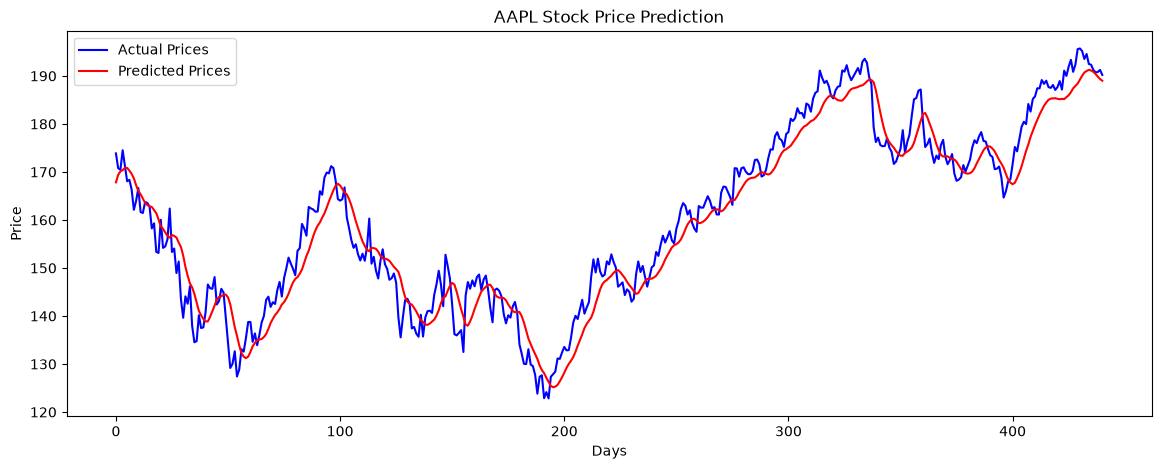

In [54]:
# 시각화
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label="Actual Prices", color='blue')
plt.plot(predictions, label="Predicted Prices", color='red')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

### 항공기 탑승객 수요 예측(LSTM)

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [56]:
# 데이터 불러오기
data_path = '../dataset/airline.csv'
df = pd.read_csv(data_path)

In [57]:
df.head()

,date,count
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [58]:
# 날짜(date)와 탑승객 수(count) 열의 이름 설정 및 변환
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

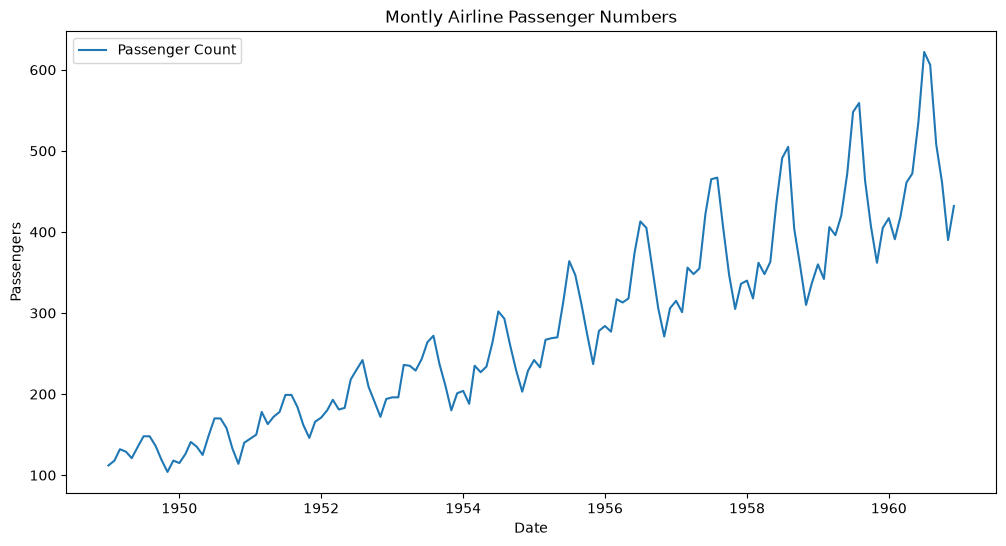

In [59]:
# 데이터 시각화 
plt.figure(figsize=(12, 6))
plt.plot(df['count'], label='Passenger Count')
plt.title('Montly Airline Passenger Numbers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

In [60]:
# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['count']])

In [62]:
# 데이터셋 분리
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [63]:
# 시계열 데이터셋 생성 함수
def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

In [64]:
time_step = 12      # 12개월 단위로 예측
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [65]:
# LSTM 입력에 맞게 데이터 형태 변경
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [66]:
# LSTM 모델 생성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(time_step, 1)),
    LSTM(32, return_sequences=False),
    Dense(16), 
    Dense(1)
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

In [68]:
# 모델 학습
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1, shuffle=False)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 253ms/step - loss: 0.0919 - val_loss: 0.2679
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0231 - val_loss: 0.0664
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0099 - val_loss: 0.0230
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0246 - val_loss: 0.0230
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0162 - val_loss: 0.0387
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0115 - val_loss: 0.0598
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0109 - val_loss: 0.0574
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0090 - val_loss: 0.0401
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0077 - val_loss: 0.0273
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0084 - val_loss: 0.0245
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0083 - val_loss: 0.0256
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0073 - val_loss: 0.0286


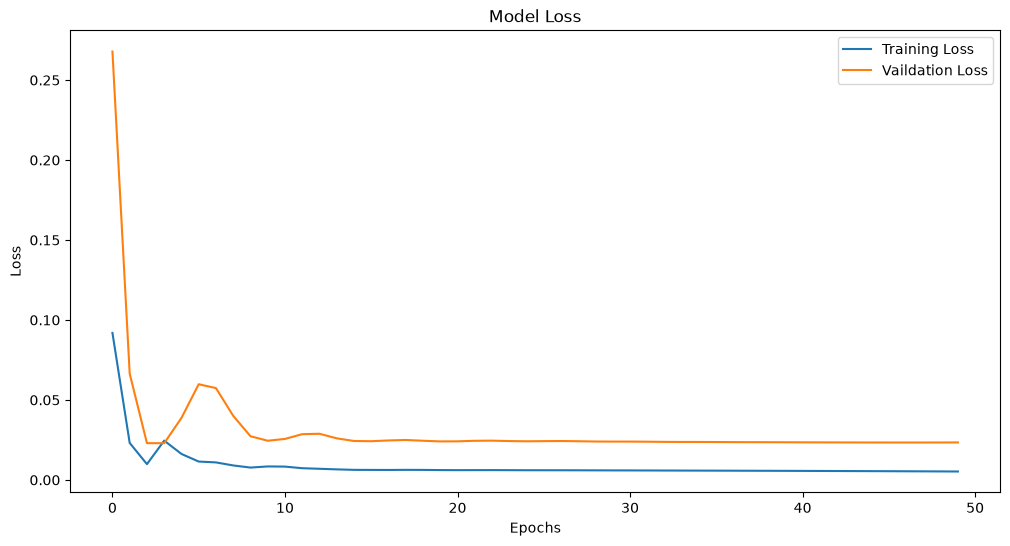

In [69]:
# 학습 과정 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Vaildation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [70]:
# 테스트 데이터 예측
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [71]:
# 예측값 역정규화
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

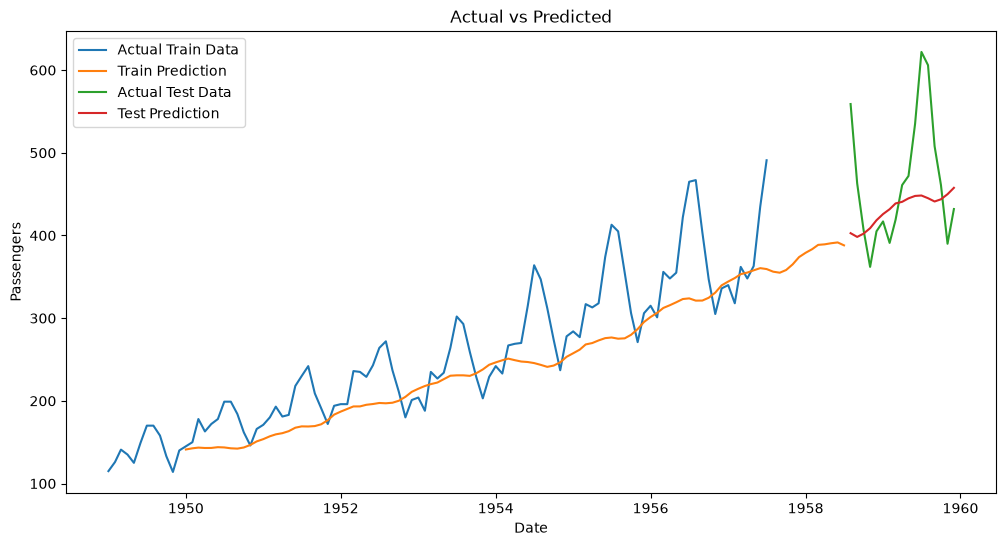

In [72]:
# 예측 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index[:len(y_train)], y_train, label='Actual Train Data')
plt.plot(df.index[time_step:len(train_predict) + time_step], train_predict, label='Train Prediction')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], y_test, label='Actual Test Data')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], test_predict, label='Test Prediction')
plt.title('Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

In [ ]:
X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

model.add(GRU(64, input_shape=(8, 1)))